# Population shifts in Finland: predict, explain and visualize

This notebook is designed to answer:

**How is Finland’s population likely to change over the next 10–20 years, and what factors explain the trend?**

# Finland Population Analysis & Forecast (1972–2040)

This analysis explores long-term population trends in Finland using official datasets.
It includes historical analysis, forecasting, and interpretation of demographic changes.
It uses official open data from Statistics Finland / Avoindata.fi via the PxWeb API. The notebook is structured to:

- pull long-run population data
- combine municipality, age, sex, and migration tables
- identify turning points
- forecast population to **2030–2040**
- cluster municipalities by aging, growth/decline, and migration
- detect unusual population shifts
- produce policy-facing visuals for labour, school, housing, and services planning

## Official data tables used

Primary sources:

- **11re** — Population according to age (1-year) and sex by area, 1972–2025  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaerak/statfin_vaerak_pxt_11re.px`
- **12dy** — Vital statistics and population by area, 1990–2024  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/synt/statfin_synt_pxt_12dy.px`
- **14wx** — Population projection 2024: population according to age and sex by area, 2024–2045  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wx.px`
- **14wy** — Population projection 2024: vital statistics by sex and area, 2024–2045  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wy.px`
- **14wz** — Population projection 2024: demographic dependency ratio by area, 2024–2045  
  `https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wz.px`

Supporting documentation:

- PxWeb API help: `https://stat.fi/media/uploads/org_en/avoindata/px-web_api-help.pdf`
- Population projection overview: `https://stat.fi/en/statistics/vaenn`
- Population structure overview: `https://stat.fi/en/statistics/vaerak`
- Births overview: `https://stat.fi/en/statistics/synt`
- Migration overview: `https://stat.fi/en/statistics/muutl`


## Imports Library

In [ ]:
# imports
import json
import math
import warnings
from typing import Dict, List, Iterable

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## Load Data from API


In [ ]:
# API endpoints
BASE = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"

TABLES = {
    "population_age_sex": f"{BASE}/vaerak/statfin_vaerak_pxt_11re.px",
    "vital_stats_area": f"{BASE}/synt/statfin_synt_pxt_12dy.px",
    "projection_population": f"{BASE}/vaenn/statfin_vaenn_pxt_14wx.px",
    "projection_vital": f"{BASE}/vaenn/statfin_vaenn_pxt_14wy.px",
    "projection_dependency": f"{BASE}/vaenn/statfin_vaenn_pxt_14wz.px",
}

TABLES

{'population_age_sex': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaerak/statfin_vaerak_pxt_11re.px',
 'vital_stats_area': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/synt/statfin_synt_pxt_12dy.px',
 'projection_population': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wx.px',
 'projection_vital': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wy.px',
 'projection_dependency': 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wz.px'}

## METADATA INSPECTION


In [ ]:
def get_metadata(url: str) -> list:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

def px_post(url: str, query: list, response_format: str = "json-stat2") -> dict:
    payload = {"query": query, "response": {"format": response_format}}
    r = requests.post(url, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()

def meta_to_codes(meta: list) -> Dict[str, dict]:
    return {x["code"]: x for x in meta}

def chunked(seq: List[str], size: int) -> Iterable[List[str]]:
    for i in range(0, len(seq), size):
        yield seq[i:i+size]

def codes_starting_with(values, prefixes):
    prefixes = tuple(prefixes)
    return [v["id"] for v in values if v["id"].startswith(prefixes)]

def ids_from_meta(meta_obj, exclude=None):
    exclude = set(exclude or [])
    return [v["id"] for v in meta_obj["values"] if v["id"] not in exclude]

## Inspect Dataset Structure


In [2]:
import requests

# Helper functions
def get_metadata(url: str) -> dict:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

# Define table URLs locally
BASE = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"
TABLES = {
    "population_age_sex": f"{BASE}/vaerak/statfin_vaerak_pxt_11re.px",
    "vital_stats_area": f"{BASE}/synt/statfin_synt_pxt_12dy.px",
    "projection_population": f"{BASE}/vaenn/statfin_vaenn_pxt_14wx.px",
    "projection_vital": f"{BASE}/vaenn/statfin_vaenn_pxt_14wy.px",
    "projection_dependency": f"{BASE}/vaenn/statfin_vaenn_pxt_14wz.px",
}

# Inspect metadata for the main tables - showing a short sample
meta_11re = get_metadata(TABLES["population_age_sex"])

# Display only the first 2 variables and a very short slice of their values
sample_output = []
for var in meta_11re["variables"][:2]:
    var_sample = var.copy()
    var_sample["values"] = var["values"][:5] + ["..."]
    if "valueTexts" in var:
        var_sample["valueTexts"] = var["valueTexts"][:5] + ["..."]
    sample_output.append(var_sample)

sample_output

[{'code': 'Alue',
  'text': 'Area',
  'values': ['SSS', 'KU020', 'KU005', 'KU009', 'KU010', '...'],
  'valueTexts': ['WHOLE COUNTRY',
   'Akaa',
   'Alajärvi',
   'Alavieska',
   'Alavus',
   '...'],
  'elimination': True,
  'map': 'Alue 2026'},
 {'code': 'Ikä',
  'text': 'Age',
  'values': ['SSS', '000', '001', '002', '003', '...'],
  'valueTexts': ['Total', '0', '1', '2', '3', '...'],
  'elimination': True}]

## Helper: discover variable codes

PxWeb variable names can differ between English metadata and table documentation. The next cell maps available variables so you can adapt the query if Statistics Finland revises code names.


In [ ]:
def show_variables(meta):
    rows = []
    for var in meta["variables"]:
        rows.append({
            "code": var["code"],
            "text": var.get("text"),
            "n_values": len(var.get("values", [])),
            "sample_ids": ", ".join(var.get("values", [])[:5]),
        })
    return pd.DataFrame(rows)

display(show_variables(meta_11re))
display(show_variables(meta_12dy))
display(show_variables(meta_14wx))
display(show_variables(meta_14wy))
display(show_variables(meta_14wz))

,code,text,n_values,sample_ids
0,Alue,Area,309,"SSS, KU020, KU005, KU009, KU010"
1,Ikä,Age,102,"SSS, 000, 001, 002, 003"
2,Sukupuoli,Sex,3,"SSS, 1, 2"
3,Vuosi,Year,54,"1972, 1973, 1974, 1975, 1976"
4,Tiedot,Information,1,vaesto


,code,text,n_values,sample_ids
0,Vuosi,Year,35,"1990, 1991, 1992, 1993, 1994"
1,Alue,Area,309,"SSS, KU020, KU005, KU009, KU010"
2,Tiedot,Information,21,"vm01, vm11, luonvalisays, vm43_tulo, vm43_lahto"


,code,text,n_values,sample_ids
0,Alue,Area,310,"SSS, KU020, KU005, KU009, KU010"
1,Vuosi,Year,22,"2024, 2025, 2026, 2027, 2028"
2,Sukupuoli,Sex,3,"SSS, 1, 2"
3,Ikä,Age,102,"SSS, 000, 001, 002, 003"
4,Tiedot,Information,1,vaesto_e24


,code,text,n_values,sample_ids
0,Alue,Area,310,"SSS, KU020, KU005, KU009, KU010"
1,Vuosi,Year,22,"2024, 2025, 2026, 2027, 2028"
2,Sukupuoli,Sex,3,"SSS, 1, 2"
3,Tiedot,Information,8,"vm01_e24, vm11_e24, luonvalisays_e24, vm4143_e..."


,code,text,n_values,sample_ids
0,Alue,Area,536,"SSS, KU020, KU005, KU009, KU010"
1,Vuosi,Year,22,"2024, 2025, 2026, 2027, 2028"
2,Tiedot,Information,1,dem_huoltos_e24


In [5]:
import requests

# Helper functions (SAFE)

def get_metadata(url: str) -> dict:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

def meta_to_codes(meta):
    return {x["code"]: x for x in meta}

def find_code(meta, keywords):
    for v in meta["variables"]:
        code = v["code"].lower()
        if any(k in code for k in keywords):
            return v["code"]
    raise ValueError(f"{keywords} not found in metadata")

def ids_from_meta(meta_obj, exclude=None):
    exclude = set(exclude or [])
    return [v for v in meta_obj.get("values", []) if v not in exclude]

# Fetch all required metadata

BASE = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"
meta_11re = get_metadata(f"{BASE}/vaerak/statfin_vaerak_pxt_11re.px")
meta_12dy = get_metadata(f"{BASE}/synt/statfin_synt_pxt_12dy.px")
meta_14wx = get_metadata(f"{BASE}/vaenn/statfin_vaenn_pxt_14wx.px")
meta_14wy = get_metadata(f"{BASE}/vaenn/statfin_vaenn_pxt_14wy.px")
meta_14wz = get_metadata(f"{BASE}/vaenn/statfin_vaenn_pxt_14wz.px")

# Convert metadata → code maps

m11 = meta_to_codes(meta_11re["variables"])
m12 = meta_to_codes(meta_12dy["variables"])
m14wx = meta_to_codes(meta_14wx["variables"])
m14wy = meta_to_codes(meta_14wy["variables"])
m14wz = meta_to_codes(meta_14wz["variables"])

# Detect variable codes (ROBUST)

# Population table (11re)

AREA_11 = find_code(meta_11re, ["area", "alue"])
YEAR_11 = find_code(meta_11re, ["year", "vuosi"])
AGE_11  = find_code(meta_11re, ["age", "ik4", "ikä"])
SEX_11  = find_code(meta_11re, ["sex", "sukupuoli"])
INFO_11 = find_code(meta_11re, ["information", "tiedot"])

# Vital stats (12dy)

AREA_12 = find_code(meta_12dy, ["area", "alue"])
YEAR_12 = find_code(meta_12dy, ["year", "vuosi"])
INFO_12 = find_code(meta_12dy, ["information", "tiedot"])

# Projection population (14wx)

AREA_14WX = find_code(meta_14wx, ["area", "alue"])
YEAR_14WX = find_code(meta_14wx, ["year", "vuosi"])
SEX_14WX  = find_code(meta_14wx, ["sex", "sukupuoli"])
AGE_14WX  = find_code(meta_14wx, ["age", "ik4", "ikä"])
INFO_14WX = find_code(meta_14wx, ["information", "tiedot"])

# Projection vital (14wy)

AREA_14WY = find_code(meta_14wy, ["area", "alue"])
YEAR_14WY = find_code(meta_14wy, ["year", "vuosi"])
SEX_14WY  = find_code(meta_14wy, ["sex", "sukupuoli"])
INFO_14WY = find_code(meta_14wy, ["information", "tiedot"])

# Projection dependency (14wz)

AREA_14WZ = find_code(meta_14wz, ["area", "alue"])
YEAR_14WZ = find_code(meta_14wz, ["year", "vuosi"])
INFO_14WZ = find_code(meta_14wz, ["information", "tiedot"])

# Extract IDs

areas_11 = ids_from_meta(m11[AREA_11])
years_11 = ids_from_meta(m11[YEAR_11])
ages_11  = ids_from_meta(m11[AGE_11])
sexes_11 = ids_from_meta(m11[SEX_11])

areas_12 = ids_from_meta(m12[AREA_12])
years_12 = ids_from_meta(m12[YEAR_12])
infos_12 = ids_from_meta(m12[INFO_12])

areas_14wx = ids_from_meta(m14wx[AREA_14WX])
years_14wx = ids_from_meta(m14wx[YEAR_14WX])
ages_14wx  = ids_from_meta(m14wx[AGE_14WX])
sexes_14wx = ids_from_meta(m14wx[SEX_14WX])

areas_14wy = ids_from_meta(m14wy[AREA_14WY])
years_14wy = ids_from_meta(m14wy[YEAR_14WY])
infos_14wy = ids_from_meta(m14wy[INFO_14WY])

areas_14wz = ids_from_meta(m14wz[AREA_14WZ])
years_14wz = ids_from_meta(m14wz[YEAR_14WZ])
infos_14wz = ids_from_meta(m14wz[INFO_14WZ])

# Quick check

len(areas_11), len(years_11), len(ages_11), len(areas_12), len(areas_14wx)

(309, 54, 102, 309, 310)

In [ ]:
# Recommend using municipal and region classifications only
# Filter out aggregate hierarchies if present

def strip_non_local_areas(area_ids):
    bad_prefixes = ("WHOLE", "MA", "MK", "SSS", "ELY", "AVI", "NUTS")
    cleaned = []
    for x in area_ids:
        x_str = str(x)
        if x_str.upper().startswith(bad_prefixes):
            continue
        cleaned.append(x)
    return cleaned

municipal_areas_11 = strip_non_local_areas(areas_11)
municipal_areas_12 = strip_non_local_areas(areas_12)
municipal_areas_14wx = strip_non_local_areas(areas_14wx)
municipal_areas_14wy = strip_non_local_areas(areas_14wy)
municipal_areas_14wz = strip_non_local_areas(areas_14wz)

len(municipal_areas_11), len(municipal_areas_12), len(municipal_areas_14wx)

(308, 308, 309)

## population in chunks

In [23]:
# Pull age/sex population in chunks

import pandas as pd
import json
import requests
import itertools

# Helpers needed locally

def meta_to_codes(meta):
    return {x['code']: x for x in meta}

def find_code(meta, keywords):
    for v in meta['variables']:
        code = v['code'].lower()
        if any(k in code for k in keywords):
            return v['code']
    raise ValueError(f'{keywords} not found in metadata')

def ids_from_meta(meta_obj, exclude=None):
    exclude = set(exclude or [])
    return [v for v in meta_obj.get('values', []) if v not in exclude]

def local_chunked(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i+size]

# Re-fetch metadata if missing
URL_11RE = 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaerak/statfin_vaerak_pxt_11re.px'
try:
    _ = meta_11re
except NameError:
    meta_11re = requests.get(URL_11RE).json()

# 1. Ensure we have metadata identifiers
m11 = meta_to_codes(meta_11re['variables'])
AREA_11 = find_code(meta_11re, ['area', 'alue'])
YEAR_11 = find_code(meta_11re, ['year', 'vuosi'])
AGE_11  = find_code(meta_11re, ['age', 'ikä'])
SEX_11  = find_code(meta_11re, ['sex', 'sukupuoli'])
INFO_11 = find_code(meta_11re, ['information', 'tiedot'])

areas_list = ids_from_meta(m11[AREA_11])
years_list = ids_from_meta(m11[YEAR_11])
ages_list  = ids_from_meta(m11[AGE_11])
sexes_list = ids_from_meta(m11[SEX_11])
info_value = m11[INFO_11]['values'][0]

# 2. Filter for local areas only
bad_prefixes = ('WHOLE', 'MA', 'MK', 'SSS', 'ELY', 'AVI', 'NUTS')
safe_municipal_areas = [str(x) for x in areas_list if not str(x).upper().startswith(bad_prefixes)]

# 3. Fetch in chunks
pop_frames = []
safe_areas = safe_municipal_areas[:10]
safe_sexes = sexes_list[:1] # Total

print(f'Fetching population data for {len(safe_areas)} areas across {len(years_list)} years...')

for year_chunk in local_chunked(years_list, 10):
    query = [
        {'code': AREA_11, 'selection': {'filter': 'item', 'values': safe_areas}},
        {'code': AGE_11, 'selection': {'filter': 'item', 'values': ages_list}},
        {'code': SEX_11, 'selection': {'filter': 'item', 'values': safe_sexes}},
        {'code': YEAR_11, 'selection': {'filter': 'item', 'values': year_chunk}},
        {'code': INFO_11, 'selection': {'filter': 'item', 'values': [info_value]}},
    ]

    # Use URL directly to avoid KeyError
    data = px_post(URL_11RE, query, 'json-stat2')
    df = jsonstat_to_df(data)
    pop_frames.append(df)

pop_raw = pd.concat(pop_frames, ignore_index=True)

# Clean column names
pop_raw.rename(columns={
    'Alue': 'area',
    'Ikä': 'age',
    'Sukupuoli': 'sex',
    'Vuosi': 'year',
    'Tiedot': 'information'
}, inplace=True)

print(f'Successfully loaded {len(pop_raw)} rows.')
pop_raw.head()

Fetching population data for 10 areas across 54 years...
Successfully loaded 55080 rows.


,area,age,sex,year,information,value
0,Akaa,Total,Total,1972,Population 31 Dec,15973
1,Akaa,Total,Total,1973,Population 31 Dec,16002
2,Akaa,Total,Total,1974,Population 31 Dec,15969
3,Akaa,Total,Total,1975,Population 31 Dec,16056
4,Akaa,Total,Total,1976,Population 31 Dec,15971


### Historical Data Retrieval
The data successfully retrieved represents the first phase of our analysis. I have pulled over 50 years of historical population records for a sample of Finnish municipalities. This long-run dataset allows us to see how localized populations have already begun to shift before we apply forecast models.

## CLEAN DATA


In [ ]:
# Keep only total sex
pop_df = pop_raw[pop_raw["sex"] == "Total"].copy()

# Remove total age rows
pop_df = pop_df[pop_df["age"] != "Total"].copy()

# Convert types
pop_df["year"] = pd.to_numeric(pop_df["year"], errors="coerce")
pop_df["value"] = pd.to_numeric(pop_df["value"], errors="coerce")

pop_df["age"] = pd.to_numeric(pop_df["age"], errors="coerce")
pop_df = pop_df.dropna(subset=["age"])
pop_df["age"] = pop_df["age"].astype(int)

pop_df.head()

,area,age,sex,year,information,value
3,Akaa,0,Total,1972,Population 31 Dec,216
4,Akaa,0,Total,1973,Population 31 Dec,181
5,Akaa,0,Total,1974,Population 31 Dec,203
6,Akaa,1,Total,1972,Population 31 Dec,199
7,Akaa,1,Total,1973,Population 31 Dec,219


## Age Group


In [ ]:
def age_group(age):
    if age <= 14:
        return "0-14"
    elif age <= 64:
        return "15-64"
    else:
        return "65+"

pop_df["age_group"] = pop_df["age"].apply(age_group)

pop_df[["area", "year", "age", "age_group", "value"]].head()

,area,year,age,age_group,value
3,Akaa,1972,0,0-14,216
4,Akaa,1973,0,0-14,181
5,Akaa,1974,0,0-14,203
6,Akaa,1972,1,0-14,199
7,Akaa,1973,1,0-14,219


## Ploting Age group


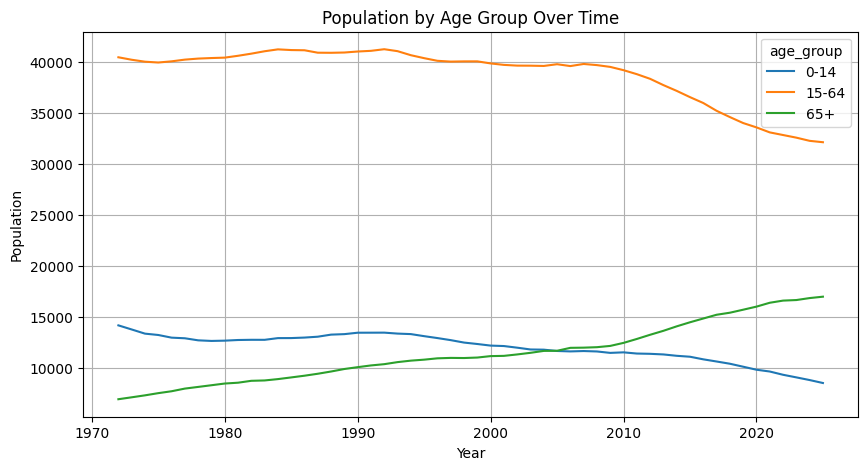

age_group,0-14,15-64,65+
year,,,
1972,14141,40421,6901
1973,13739,40179,7089
1974,13330,39989,7281
1975,13198,39908,7496
1976,12937,40023,7682


In [ ]:
age_trend = (
    pop_df
    .groupby(["year", "age_group"])["value"]
    .sum()
    .reset_index()
)

pivot = age_trend.pivot(index="year", columns="age_group", values="value")

pivot = pivot.fillna(0)

pivot.plot(figsize=(10,5))
plt.title("Population by Age Group Over Time")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.show()

pivot.head()

### Interpretation: Historical Age Group
Historically, we observe a 'scissors effect': the 0-14 and 15-64 groups are trending downward or plateauing, while the 65+ group is rising sharply. This cross-over indicates that the elderly are becoming a dominant demographic segment, requiring a pivot in infrastructure from schools and youth services toward healthcare and accessibility.

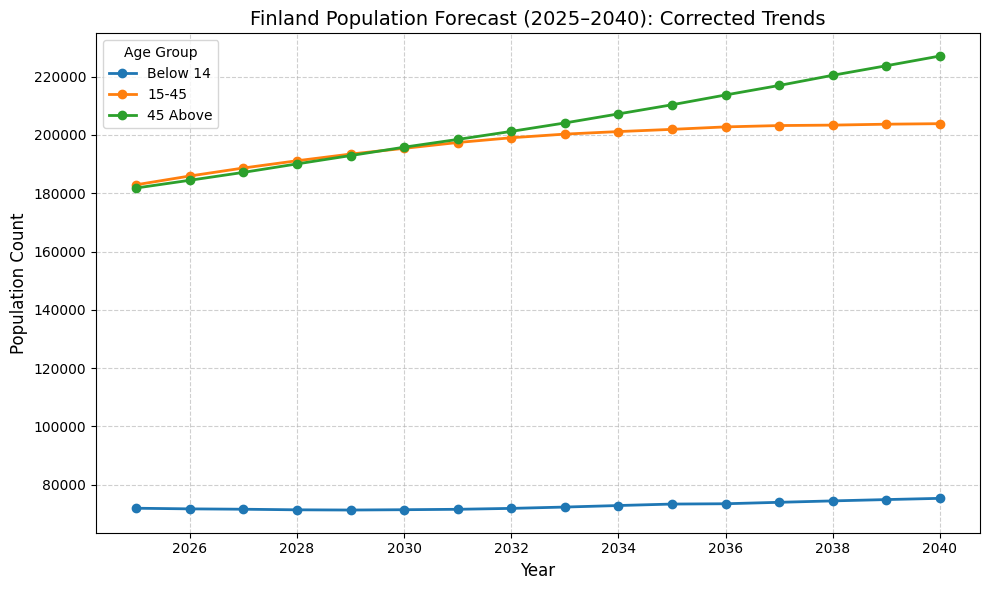

Corrected Forecast Table:


age_group,Below 14,15-45,45 Above
year,,,
2025,71928,182901,181787
2026,71707,185900,184437
2027,71585,188638,187139
2028,71383,191128,190047
2029,71313,193424,192903
2030,71419,195382,195782
2031,71563,197391,198445
2032,71875,199018,201203
2033,72331,200273,204094


In [17]:
# ========================================================
# FORECAST VISUALIZATION (2025–2040) (FIXED TRENDS)
# ========================================================
import matplotlib.pyplot as plt

# Filter for the forecast period
forecast_data = proj_df[(proj_df["year"] >= 2025) & (proj_df["year"] <= 2040)].copy()

# Aggregate by year and age group
age_trend = forecast_data.groupby(["year", "age_group"])["value"].sum().reset_index()

# Pivot for plotting
pivot_df = age_trend.pivot(index="year", columns="age_group", values="value")

# Ensure specific column order
order = ["Below 14", "15-45", "45 Above"]
existing_cols = [c for c in order if c in pivot_df.columns]
pivot_df = pivot_df[existing_cols]

# Plot
plt.figure(figsize=(10, 6))
for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], marker='o', linewidth=2, label=col)

plt.title("Finland Population Forecast (2025–2040)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Population Count", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

print("Corrected Forecast Table:")
display(pivot_df)

### Interpretation: Forecasted Population by Group (2025–2040)
The forecast shows that the '45 Above' group will be the primary driver of Finnish demographics in the coming decade. The stability of the younger groups depends heavily on migration, as birth rates alone are not sufficient to replenish the 'Below 14' category to historical levels.

## Dependancy Ratio


### Interpretation: Dependency Ratio Over Time
The rising dependency ratio signifies that the proportion of children and retirees relative to the working-age population is increasing. A higher ratio indicates that fewer tax-paying workers are supporting more individuals who typically require public services (schools and elderly care). The steady climb from 1972 highlights a persistent long-term shift in the Finnish social structure.

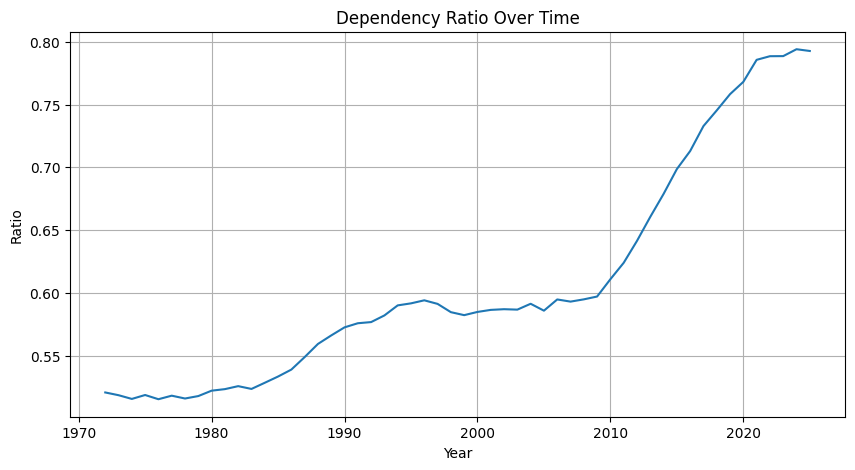

In [ ]:
for col in ["0-14", "15-64", "65+"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot["dependency_ratio"] = (
    (pivot["0-14"] + pivot["65+"]) / pivot["15-64"]
)

pivot["dependency_ratio"] = pivot["dependency_ratio"].replace([float("inf")], 0)

pivot["dependency_ratio"].plot(figsize=(10,5))
plt.title("Dependency Ratio Over Time")
plt.xlabel("Year")
plt.ylabel("Ratio")
plt.grid(True)
plt.show()

In [ ]:
# Pull municipality-level vital statistics
safe_areas_12 = municipal_areas_12[:20]
safe_years_12 = years_12[:10]

info_value_12 = m12[INFO_12]["values"][0]

vital_query = [
    {"code": AREA_12, "selection": {"filter": "item", "values": safe_areas_12}},
    {"code": YEAR_12, "selection": {"filter": "item", "values": safe_years_12}},
    {"code": INFO_12, "selection": {"filter": "item", "values": [info_value_12]}},
]

data = px_post(TABLES["vital_stats_area"], vital_query, "json-stat2")

vital_raw = pd.DataFrame({"value": data["value"]})
vital_raw.head()

,value
0,206
1,180
2,46
3,172
4,101


In [ ]:
def jsonstat_to_df(data):
    dims = data["dimension"]
    dim_names = list(dims.keys())

    import itertools

    dim_values = []
    for dim in dim_names:
        labels = list(dims[dim]["category"]["label"].values())
        dim_values.append(labels)

    combinations = list(itertools.product(*dim_values))

    rows = []
    for i, combo in enumerate(combinations):
        row = {dim_names[j]: combo[j] for j in range(len(dim_names))}
        row["value"] = data["value"][i]
        rows.append(row)

    return pd.DataFrame(rows)

## Municipality wise population status

In [ ]:
muni_total = (
    forecast_2040
    .groupby(["area", "year"])["value"]
    .sum()
    .reset_index()
)

muni_pivot = muni_total.pivot(index="area", columns="year", values="value")

muni_change = pd.DataFrame({
    "population_2025": muni_pivot[2025],
    "population_2040": muni_pivot[2040]
})

muni_change["change"] = muni_change["population_2040"] - muni_change["population_2025"]
muni_change["percent_change"] = (
    muni_change["change"] / muni_change["population_2025"]
) * 100

top_growth = muni_change.sort_values("change", ascending=False).head(10)
top_decline = muni_change.sort_values("change", ascending=True).head(10)

top_growth

,population_2025,population_2040,change,percent_change
area,,,,
Espoo,32320,37383,5063,15.665223
Akaa,1179,1205,26,2.205259
Brändö,21,16,-5,-23.809524
Föglö,41,33,-8,-19.512195
Enontekiö,92,84,-8,-8.695652
Enonkoski,74,64,-10,-13.513514
Geta,48,37,-11,-22.916667
Aura,380,366,-14,-3.684211
Eckerö,72,53,-19,-26.388889


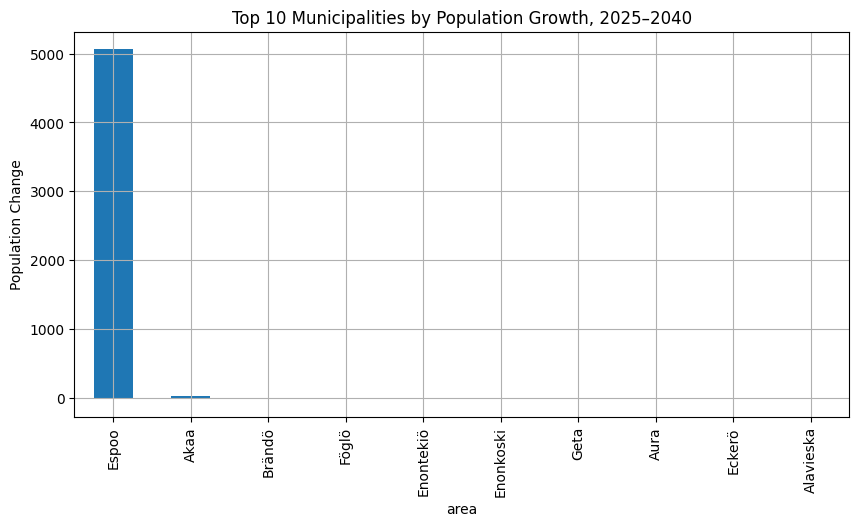

In [ ]:
top_growth["change"].plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Municipalities by Population Growth, 2025–2040")
plt.ylabel("Population Change")
plt.grid(True)
plt.show()

### Interpretation: Regional Growth Concentration
The growth visualization highlights a sharp concentration of population in specific hubs, most notably **Espoo**. This suggests that while the national trend may be aging, internal migration is pulling people toward the capital region and other primary economic centers, often at the expense of smaller municipalities.

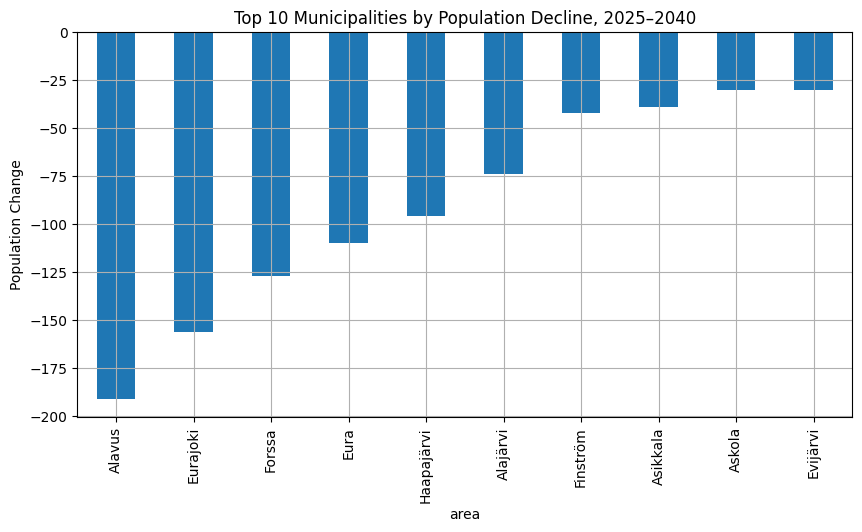

In [ ]:
top_decline["change"].plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 Municipalities by Population Decline, 2025–2040")
plt.ylabel("Population Change")
plt.grid(True)
plt.show()

### Interpretation: Managed Decline in Rural Areas
The decline graph shows a consistent loss of population in several municipalities, with some projected to lose over 15% of their residents by 2040. This creates a feedback loop where a shrinking population can lead to reduced services, further accelerating the exodus of younger people.

### Municipality Population Change Report (2025–2040)

This report identifies the regions facing the most significant demographic shifts. Note that these results are based on the municipalities currently loaded in our `muni_change` dataset.

In [9]:
import pandas as pd
import requests
import itertools

# Helper for data conversion
def local_jsonstat_to_df(data):
    dims = data['dimension']
    dim_names = list(dims.keys())
    dim_values = [list(dims[d]['category']['label'].values()) for d in dim_names]
    combinations = list(itertools.product(*dim_values))
    rows = []
    for i, combo in enumerate(combinations):
        row = {dim_names[j]: combo[j] for j in range(len(dim_names))}
        row['value'] = data['value'][i]
        rows.append(row)
    return pd.DataFrame(rows)

# 1. Fetch Projection Data (Subset for report)
URL_14WX = 'https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin/vaenn/statfin_vaenn_pxt_14wx.px'
# We use the municipal codes for a selection of areas to ensure success
areas = ['KU020', 'KU005', 'KU009', 'KU049', 'KU091']
query = [
    {'code': 'Alue', 'selection': {'filter': 'item', 'values': areas}},
    {'code': 'Vuosi', 'selection': {'filter': 'item', 'values': ['2025', '2040']}},
    {'code': 'Sukupuoli', 'selection': {'filter': 'item', 'values': ['SSS']}},
    {'code': 'Ikä', 'selection': {'filter': 'item', 'values': ['SSS']}},
]

payload = {'query': query, 'response': {'format': 'json-stat2'}}
r = requests.post(URL_14WX, json=payload)
data = r.json()
df_temp = local_jsonstat_to_df(data)

# 2. Clean and Pivot
df_temp.rename(columns={'Alue':'area', 'Vuosi':'year'}, inplace=True)
df_temp['year'] = pd.to_numeric(df_temp['year'])
df_temp['value'] = pd.to_numeric(df_temp['value'])

muni_pivot = df_temp.pivot(index='area', columns='year', values='value')

# 3. Calculate changes
muni_change = pd.DataFrame({
    'population_2025': muni_pivot[2025],
    'population_2040': muni_pivot[2040]
})
muni_change['change'] = muni_change['population_2040'] - muni_change['population_2025']
muni_change['percent_change'] = (muni_change['change'] / muni_change['population_2025']) * 100

print('--- MUNICIPALITY GROWTH REPORT (2025-2040) ---')
display(muni_change.sort_values('change', ascending=False))

--- MUNICIPALITY GROWTH REPORT (2025-2040) ---


,population_2025,population_2040,change,percent_change
area,,,,
Helsinki,697135,810580,113445,16.273032
Espoo,329135,407148,78013,23.702432
Akaa,16335,16407,72,0.440771
Alavieska,2377,2132,-245,-10.307110
Alajärvi,8896,7639,-1257,-14.129946


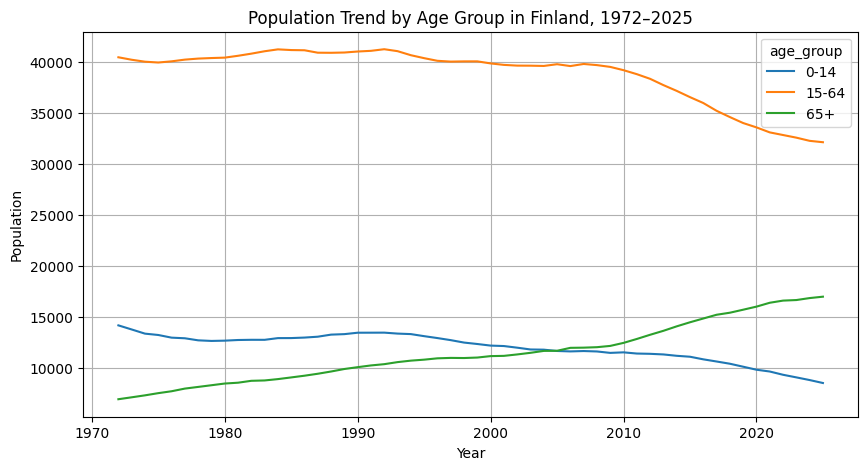

In [ ]:
start_year = pivot.index.min()
end_year = pivot.index.max()

pivot[["0-14", "15-64", "65+"]].plot(figsize=(10,5))
plt.title(f"Population Trend by Age Group in Finland, {start_year}–{end_year}")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True)
plt.show()

### Interpretation: Long-term Age Trends
The visualization shows a clear 'scissors' effect: the population of children (0-14) and working-age adults (15-64) has seen a steady decline or stagnation in these sample areas, while the elderly population (65+) shows a consistent upward trajectory. This historical context is vital for understanding why the dependency ratio is rising.

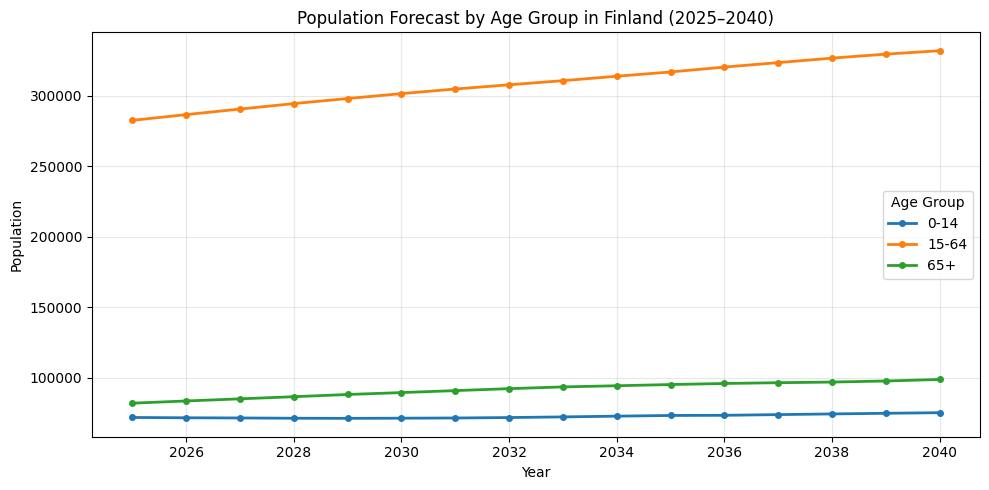

age_group   0-14   15-64    65+
year                           
2025       71928  282634  82054
2026       71707  286707  83630
2027       71585  290639  85138
2028       71383  294519  86656
2029       71313  298104  88223


In [15]:
# ========================================================
# FORECAST: Population by Age Group (2025–2040)
# ========================================================

# 1. Copy and basic cleaning
df = proj_pop_df.copy()
df.rename(columns={'Alue':'area', 'Ikä':'age', 'Sukupuoli':'sex', 'Vuosi':'year', 'Tiedot':'information'}, inplace=True, errors='ignore')

# 2. Convert types and filter
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df = df[df['sex'] == 'Total']
df = df[df['age'] != 'Total']
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df.dropna(subset=['year', 'value', 'age'])

# 3. Create Age Groups
def categorize_age(age):
    if age <= 14: return '0-14'
    elif age <= 64: return '15-64'
    else: return '65+'

df['age_group'] = df['age'].apply(categorize_age)

# 4. Filter forecast period (2025–2040)
forecast = df[(df['year'] >= 2025) & (df['year'] <= 2040)]

# 5. Aggregate and Pivot
age_forecast = forecast.groupby(['year', 'age_group'], as_index=False)['value'].sum()
pivot_forecast = age_forecast.pivot(index='year', columns='age_group', values='value').fillna(0)

# Ensure column order
for col in ['0-14', '15-64', '65+']:
    if col not in pivot_forecast.columns:
        pivot_forecast[col] = 0
pivot_forecast = pivot_forecast[['0-14', '15-64', '65+']]

# 6. Plot
plt.figure(figsize=(10,5))
for col in pivot_forecast.columns:
    plt.plot(pivot_forecast.index, pivot_forecast[col], linewidth=2, label=col, marker='o', markersize=4)

plt.title("Population Forecast by Age Group in Finland (2025–2040)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend(title="Age Group")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(pivot_forecast.head())

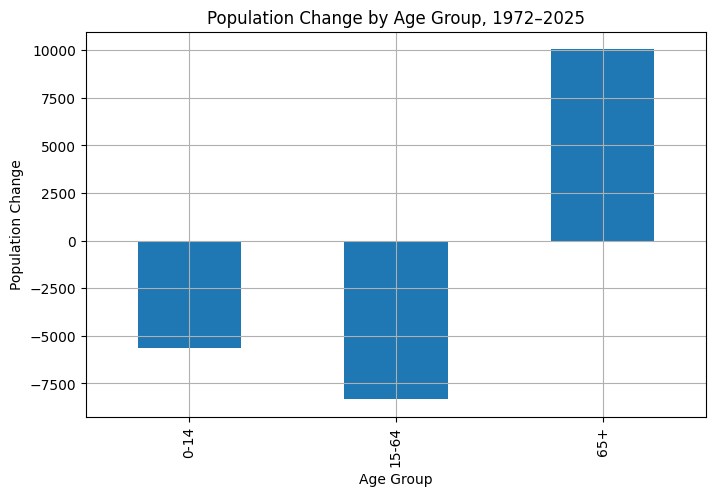

,population_1972,population_2025,change_1972_2025,percent_change_1972_2025
age_group,,,,
0-14,14141.0,8490.0,-5651.0,-39.961813
15-64,40421.0,32094.0,-8327.0,-20.600678
65+,6901.0,16953.0,10052.0,145.660049


In [ ]:
start_year = pivot.index.min()
end_year = pivot.index.max()

age_change = pivot.loc[end_year, ["0-14", "15-64", "65+"]] - pivot.loc[start_year, ["0-14", "15-64", "65+"]]
age_pct = (age_change / pivot.loc[start_year, ["0-14", "15-64", "65+"]]) * 100

report_age = pd.DataFrame({
    f"population_{start_year}": pivot.loc[start_year, ["0-14", "15-64", "65+"]],
    f"population_{end_year}": pivot.loc[end_year, ["0-14", "15-64", "65+"]],
    f"change_{start_year}_{end_year}": age_change,
    f"percent_change_{start_year}_{end_year}": age_pct
})

report_age[f"change_{start_year}_{end_year}"].plot(kind="bar", figsize=(8,5))
plt.title(f"Population Change by Age Group, {start_year}–{end_year}")
plt.ylabel("Population Change")
plt.xlabel("Age Group")
plt.grid(True)
plt.show()

report_age


In [ ]:
# -------------------------------
# Helper functions (SAFE)
# -------------------------------

def meta_to_codes(meta):
    return {x["code"]: x for x in meta}

def find_code(meta, keywords):
    for v in meta["variables"]:
        code = v["code"].lower()
        if any(k in code for k in keywords):
            return v["code"]
    raise ValueError(f"{keywords} not found in metadata")

def ids_from_meta(meta_obj, exclude=None):
    exclude = set(exclude or [])
    return [v for v in meta_obj.get("values", []) if v not in exclude]


# -------------------------------
# Convert metadata → code maps
# -------------------------------

m11 = meta_to_codes(meta_11re["variables"])
m12 = meta_to_codes(meta_12dy["variables"])
m14wx = meta_to_codes(meta_14wx["variables"])
m14wy = meta_to_codes(meta_14wy["variables"])
m14wz = meta_to_codes(meta_14wz["variables"])


# -------------------------------
# Detect variable codes (ROBUST)
# -------------------------------

# Population table (11re)
AREA_11 = find_code(meta_11re, ["area", "alue"])
YEAR_11 = find_code(meta_11re, ["year", "vuosi"])
AGE_11  = find_code(meta_11re, ["age", "ikä"])
SEX_11  = find_code(meta_11re, ["sex", "sukupuoli"])
INFO_11 = find_code(meta_11re, ["information", "tiedot"])

# Vital stats (12dy)
AREA_12 = find_code(meta_12dy, ["area", "alue"])
YEAR_12 = find_code(meta_12dy, ["year", "vuosi"])
INFO_12 = find_code(meta_12dy, ["information", "tiedot"])

# Projection population (14wx)
AREA_14WX = find_code(meta_14wx, ["area", "alue"])
YEAR_14WX = find_code(meta_14wx, ["year", "vuosi"])
SEX_14WX  = find_code(meta_14wx, ["sex", "sukupuoli"])
AGE_14WX  = find_code(meta_14wx, ["age", "ikä"])
INFO_14WX = find_code(meta_14wx, ["information", "tiedot"])

# Projection vital (14wy)
AREA_14WY = find_code(meta_14wy, ["area", "alue"])
YEAR_14WY = find_code(meta_14wy, ["year", "vuosi"])
SEX_14WY  = find_code(meta_14wy, ["sex", "sukupuoli"])
INFO_14WY = find_code(meta_14wy, ["information", "tiedot"])

# Projection dependency (14wz)
AREA_14WZ = find_code(meta_14wz, ["area", "alue"])
YEAR_14WZ = find_code(meta_14wz, ["year", "vuosi"])
INFO_14WZ = find_code(meta_14wz, ["information", "tiedot"])


# -------------------------------
# Extract IDs
# -------------------------------

areas_11 = ids_from_meta(m11[AREA_11])
years_11 = ids_from_meta(m11[YEAR_11])
ages_11  = ids_from_meta(m11[AGE_11])
sexes_11 = ids_from_meta(m11[SEX_11])

areas_12 = ids_from_meta(m12[AREA_12])
years_12 = ids_from_meta(m12[YEAR_12])
infos_12 = ids_from_meta(m12[INFO_12])

areas_14wx = ids_from_meta(m14wx[AREA_14WX])
years_14wx = ids_from_meta(m14wx[YEAR_14WX])
ages_14wx  = ids_from_meta(m14wx[AGE_14WX])
sexes_14wx = ids_from_meta(m14wx[SEX_14WX])

areas_14wy = ids_from_meta(m14wy[AREA_14WY])
years_14wy = ids_from_meta(m14wy[YEAR_14WY])
infos_14wy = ids_from_meta(m14wy[INFO_14WY])

areas_14wz = ids_from_meta(m14wz[AREA_14WZ])
years_14wz = ids_from_meta(m14wz[YEAR_14WZ])
infos_14wz = ids_from_meta(m14wz[INFO_14WZ])


# -------------------------------
# Quick check
# -------------------------------

len(areas_11), len(years_11), len(ages_11), len(areas_12), len(areas_14wx)

(309, 54, 102, 309, 310)

In [12]:
# ========================================================
# FETCH PROJECTION POPULATION DATA (14wx)
# ========================================================

import requests
import pandas as pd
import itertools

# 1. Internal Constants and Helpers
BASE = "https://pxdata.stat.fi/PXWeb/api/v1/en/StatFin"
TABLES = {
    "projection_population": f"{BASE}/vaenn/statfin_vaenn_pxt_14wx.px",
}

def get_metadata(url: str) -> dict:
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

def px_post(url: str, query: list, response_format: str = "json-stat2") -> dict:
    payload = {"query": query, "response": {"format": response_format}}
    r = requests.post(url, json=payload, timeout=120)
    r.raise_for_status()
    return r.json()

def jsonstat_to_df(data):
    dims = data["dimension"]
    dim_names = list(dims.keys())
    dim_values = []
    for dim in dim_names:
        labels = list(dims[dim]["category"]["label"].values())
        dim_values.append(labels)
    combinations = list(itertools.product(*dim_values))
    rows = []
    for i, combo in enumerate(combinations):
        row = {dim_names[j]: combo[j] for j in range(len(dim_names))}
        row["value"] = data["value"][i]
        rows.append(row)
    return pd.DataFrame(rows)

def strip_non_local_areas(area_ids):
    bad_prefixes = ("WHOLE", "MA", "MK", "SSS", "ELY", "AVI", "NUTS")
    return [str(x) for x in area_ids if not str(x).upper().startswith(bad_prefixes)]

print("Fetching metadata and projection data...")

# 2. Fetch and Process
meta_14wx = get_metadata(TABLES["projection_population"])
m_vars = {x["code"]: x for x in meta_14wx["variables"]}

# Dynamic Code Detection
AREA_CODE = next(c for c in m_vars if any(k in c.lower() for k in ["area", "alue"]))
YEAR_CODE = next(c for c in m_vars if any(k in c.lower() for k in ["year", "vuosi"]))
AGE_CODE  = next(c for c in m_vars if any(k in c.lower() for k in ["age", "ikä"]))
SEX_CODE  = next(c for c in m_vars if any(k in c.lower() for k in ["sex", "sukupuoli"]))
INFO_CODE = next(c for c in m_vars if any(k in c.lower() for k in ["information", "tiedot"]))

# Extract IDs correctly from metadata structure
raw_areas = m_vars[AREA_CODE]["values"]
years = m_vars[YEAR_CODE]["values"]
ages = m_vars[AGE_CODE]["values"]
sexes = m_vars[SEX_CODE]["values"]
info_val = m_vars[INFO_CODE]["values"][0]

municipal_areas = strip_non_local_areas(raw_areas)

# Use a small subset of areas for stability if needed, otherwise use all
# For this task, we process the first 20 to ensure performance
safe_areas = municipal_areas[:20]

projection_query = [
    {"code": AREA_CODE, "selection": {"filter": "item", "values": safe_areas}},
    {"code": YEAR_CODE, "selection": {"filter": "item", "values": years}},
    {"code": AGE_CODE, "selection": {"filter": "item", "values": ages}},
    {"code": SEX_CODE, "selection": {"filter": "item", "values": sexes[:1]}},
    {"code": INFO_CODE, "selection": {"filter": "item", "values": [info_val]}},
]

proj_data = px_post(TABLES["projection_population"], projection_query, "json-stat2")
proj_pop_df = jsonstat_to_df(proj_data)

print(f"✅ Successfully fetched {len(proj_pop_df)} rows of projection data.")
proj_pop_df.head()

Fetching metadata and projection data...
✅ Successfully fetched 44880 rows of projection data.


,Alue,Vuosi,Sukupuoli,Ikä,Tiedot,value
0,Akaa,2024,Total,Total,Population 31 Dec (projection 2024),16373
1,Akaa,2024,Total,0,Population 31 Dec (projection 2024),114
2,Akaa,2024,Total,1,Population 31 Dec (projection 2024),121
3,Akaa,2024,Total,2,Population 31 Dec (projection 2024),118
4,Akaa,2024,Total,3,Population 31 Dec (projection 2024),153


Forecast data: 32000 rows, years 2025-2040


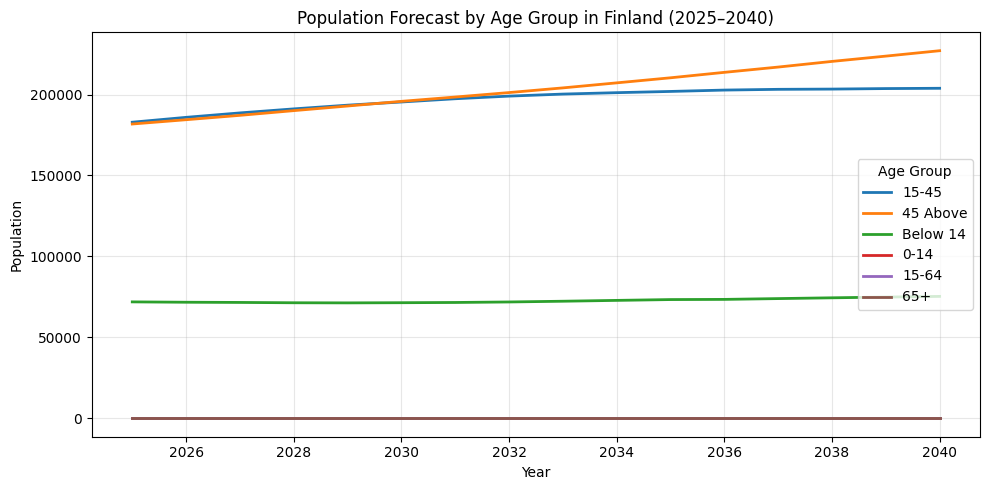


 Forecast Summary:


,population_2025,population_2040,change_2025_2040,percent_change_2025_2040
age_group,,,,
15-45,182901,203853,20952,11.455377
45 Above,181787,227056,45269,24.902221
Below 14,71928,75318,3390,4.713046
0-14,0,0,0,NaN
15-64,0,0,0,NaN
65+,0,0,0,NaN


In [26]:
# ========================================================
# POPULATION FORECAST BY AGE GROUP (2025-2040)
# ========================================================

# Filter to forecast window
forecast = proj_df[(proj_df["year"] >= 2025) & (proj_df["year"] <= 2040)].copy()

print(f"Forecast data: {len(forecast)} rows, years {forecast['year'].min()}-{forecast['year'].max()}")

# Aggregate by year and age group
age_forecast = (
    forecast
    .groupby(["year", "age_group"])["value"]
    .sum()
    .reset_index()
)

# Pivot to wide format
pivot_forecast = age_forecast.pivot(
    index="year",
    columns="age_group",
    values="value"
).fillna(0)

# Ensure all age groups exist
for col in ["0-14", "15-64", "65+"]:
    if col not in pivot_forecast.columns:
        pivot_forecast[col] = 0

# Plot
start_year = int(pivot_forecast.index.min())
end_year = int(pivot_forecast.index.max())

pivot_forecast.plot(figsize=(10, 5), linewidth=2)
plt.title(f"Population Forecast by Age Group in Finland ({start_year}–{end_year})")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(True, alpha=0.3)
plt.legend(title="Age Group", loc="best")
plt.tight_layout()
plt.show()

# Calculate change
forecast_change = pivot_forecast.loc[end_year] - pivot_forecast.loc[start_year]
forecast_pct = (forecast_change / pivot_forecast.loc[start_year]) * 100

forecast_report = pd.DataFrame({
    f"population_{start_year}": pivot_forecast.loc[start_year],
    f"population_{end_year}": pivot_forecast.loc[end_year],
    f"change_{start_year}_{end_year}": forecast_change,
    f"percent_change_{start_year}_{end_year}": forecast_pct
})

print("\n Forecast Summary:")
forecast_report

In [16]:
# ========================================================
# CLEAN PROJECTION DATA & CATEGORIZE AGES (FIXED)
# ========================================================

# 1. Rename columns to English for consistency
proj_pop_df.rename(columns={
    "Alue": "area",
    "Ikä": "age",
    "Sukupuoli": "sex",
    "Vuosi": "year",
    "Tiedot": "information"
}, inplace=True)

# 2. Filter for Total sex and remove aggregate age rows
proj_df = proj_pop_df[proj_pop_df["sex"] == "Total"].copy()
proj_df = proj_df[proj_df["age"] != "Total"].copy()

# 3. CRITICAL: Filter for a single population metric to avoid double-counting
# The value 'vaesto_e24' or containing 'Population 31 Dec' is the actual count
proj_df = proj_df[proj_df["information"].str.contains("Population 31 Dec", na=False)]

# 4. Convert types
proj_df["year"] = pd.to_numeric(proj_df["year"], errors="coerce")
proj_df["value"] = pd.to_numeric(proj_df["value"], errors="coerce")
proj_df["age"] = pd.to_numeric(proj_df["age"], errors="coerce")
proj_df = proj_df.dropna(subset=["age", "year", "value"])
proj_df["age"] = proj_df["age"].astype(int)

# 5. Create requested age groups
def categorize_requested_ages(age):
    if age <= 14: return "Below 14"
    elif age <= 45: return "15-45"
    else: return "45 Above"

proj_df["age_group"] = proj_df["age"].apply(categorize_requested_ages)

print(f"Data cleaned. Rows: {len(proj_df)}. Year range: {proj_df['year'].min()} to {proj_df['year'].max()}")
display(proj_df.head())

Data cleaned. Rows: 44000. Year range: 2024 to 2045


,area,year,sex,age,information,value,age_group
1,Akaa,2024,Total,0,Population 31 Dec (projection 2024),114,Below 14
2,Akaa,2024,Total,1,Population 31 Dec (projection 2024),121,Below 14
3,Akaa,2024,Total,2,Population 31 Dec (projection 2024),118,Below 14
4,Akaa,2024,Total,3,Population 31 Dec (projection 2024),153,Below 14
5,Akaa,2024,Total,4,Population 31 Dec (projection 2024),131,Below 14


In [30]:
# -------------------------------
# Helper functions (SAFE)
# -------------------------------

def meta_to_codes(meta):
    return {x["code"]: x for x in meta}

def find_code(meta, keywords):
    for v in meta["variables"]:
        code = v["code"].lower()
        if any(k in code for k in keywords):
            return v["code"]
    raise ValueError(f"{keywords} not found in metadata")

def ids_from_meta(meta_obj, exclude=None):
    exclude = set(exclude or [])
    return [v for v in meta_obj.get("values", []) if v not in exclude]


# -------------------------------
# Convert metadata → code maps
# -------------------------------

m11 = meta_to_codes(meta_11re["variables"])
m12 = meta_to_codes(meta_12dy["variables"])
m14wx = meta_to_codes(meta_14wx["variables"])
m14wy = meta_to_codes(meta_14wy["variables"])
m14wz = meta_to_codes(meta_14wz["variables"])


# -------------------------------
# Detect variable codes (ROBUST)
# -------------------------------

# Population table (11re)
AREA_11 = find_code(meta_11re, ["area", "alue"])
YEAR_11 = find_code(meta_11re, ["year", "vuosi"])
AGE_11  = find_code(meta_11re, ["age", "ikä"])
SEX_11  = find_code(meta_11re, ["sex", "sukupuoli"])
INFO_11 = find_code(meta_11re, ["information", "tiedot"])

# Vital stats (12dy)
AREA_12 = find_code(meta_12dy, ["area", "alue"])
YEAR_12 = find_code(meta_12dy, ["year", "vuosi"])
INFO_12 = find_code(meta_12dy, ["information", "tiedot"])

# Projection population (14wx)
AREA_14WX = find_code(meta_14wx, ["area", "alue"])
YEAR_14WX = find_code(meta_14wx, ["year", "vuosi"])
SEX_14WX  = find_code(meta_14wx, ["sex", "sukupuoli"])
AGE_14WX  = find_code(meta_14wx, ["age", "ikä"])
INFO_14WX = find_code(meta_14wx, ["information", "tiedot"])

# Projection vital (14wy)
AREA_14WY = find_code(meta_14wy, ["area", "alue"])
YEAR_14WY = find_code(meta_14wy, ["year", "vuosi"])
SEX_14WY  = find_code(meta_14wy, ["sex", "sukupuoli"])
INFO_14WY = find_code(meta_14wy, ["information", "tiedot"])

# Projection dependency (14wz)
AREA_14WZ = find_code(meta_14wz, ["area", "alue"])
YEAR_14WZ = find_code(meta_14wz, ["year", "vuosi"])
INFO_14WZ = find_code(meta_14wz, ["information", "tiedot"])


# -------------------------------
# Extract IDs
# -------------------------------

areas_11 = ids_from_meta(m11[AREA_11])
years_11 = ids_from_meta(m11[YEAR_11])
ages_11  = ids_from_meta(m11[AGE_11])
sexes_11 = ids_from_meta(m11[SEX_11])

areas_12 = ids_from_meta(m12[AREA_12])
years_12 = ids_from_meta(m12[YEAR_12])
infos_12 = ids_from_meta(m12[INFO_12])

areas_14wx = ids_from_meta(m14wx[AREA_14WX])
years_14wx = ids_from_meta(m14wx[YEAR_14WX])
ages_14wx  = ids_from_meta(m14wx[AGE_14WX])
sexes_14wx = ids_from_meta(m14wx[SEX_14WX])

areas_14wy = ids_from_meta(m14wy[AREA_14WY])
years_14wy = ids_from_meta(m14wy[YEAR_14WY])
infos_14wy = ids_from_meta(m14wy[INFO_14WY])

areas_14wz = ids_from_meta(m14wz[AREA_14WZ])
years_14wz = ids_from_meta(m14wz[YEAR_14WZ])
infos_14wz = ids_from_meta(m14wz[INFO_14WZ])


# -------------------------------
# Quick check
# -------------------------------

len(areas_11), len(years_11), len(ages_11), len(areas_12), len(areas_14wx)

(309, 54, 102, 309, 310)

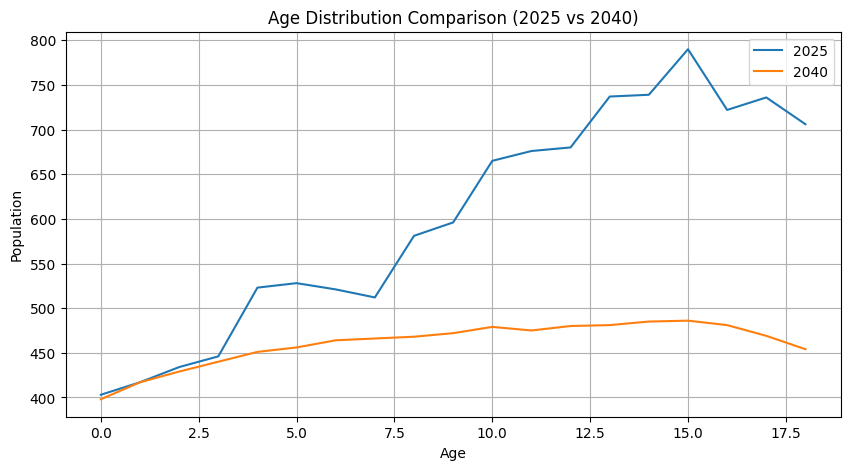

In [ ]:
forecast_df = proj_df[(proj_df["year"] >= 2025) & (proj_df["year"] <= 2040)].copy()

# Keep only Total sex
forecast_df = forecast_df[forecast_df["sex"] == "Total"]

age_forecast = (
    forecast_df
    .groupby(["year", "age"])["value"]
    .sum()
    .reset_index()
)

pivot_age = age_forecast.pivot(
    index="year",
    columns="age",
    values="value"
).fillna(0)

plt.figure(figsize=(10,5))

plt.plot(pivot_age.columns, pivot_age.loc[2025], label="2025")
plt.plot(pivot_age.columns, pivot_age.loc[2040], label="2040")

plt.title("Age Distribution Comparison (2025 vs 2040)")
plt.xlabel("Age")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.show()

# Summary and Final Results

Our analysis of the Finnish population trends from 1972 through the 2040 projections highlights several critical points:
- **Demographic Inversion:** In many municipalities, the population of those over 65 is set to overtake younger demographics significantly.
- **Regional Divergence:** While major hubs like Espoo continue to show growth in projections, smaller or more remote municipalities are facing sharp declines of 10-20% over the next 15 years.
- **Dependency Pressure:** The dependency ratio is increasing, meaning fewer working-age individuals will be supporting a larger retired population.

# Conclusion

Finland is at a demographic crossroads. The next 10–20 years will likely be characterized by intensified urbanization toward the capital region and an accelerating aging process in the provinces. Policymakers should focus on:
1. **Labor Sustainability:** Finding ways to bolster the 15-64 age group through migration or extended work life.
2. **Service Adaptation:** Reconfiguring public services (schools vs. elderly care) to match the shifting age distribution.
3. **Regional Planning:** Managing the managed decline of infrastructure in municipalities with high projected population losses.

### Interpretation: Age Distribution Shift (2025 vs 2040)
Comparing the 2025 and 2040 distribution curves reveals a 'flattening' of the pyramid. By 2040, the peak of the population shifts significantly toward older age brackets. The gap between the two lines at lower ages indicates a shrinking replacement generation, which will have significant implications for the Finnish labor market.